In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# anchor to repo root by walking up to pyproject.toml — works regardless of kernel CWD
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "data" / "raw"

txn = pd.read_csv(DATA / "train_transaction.csv")
idn = pd.read_csv(DATA / "train_identity.csv")

df = txn.merge(idn, on="TransactionID", how="left")
del txn, idn   # free ~2GB — we only need the merged frame

print("merged:", df.shape)


merged: (590540, 434)


min: 86400 max: 15811131
span in days: 181.99920138888888
sorted by TransactionDT: True
TransactionDT      seconds from a reference point (the time axis)
TransactionAmt     transaction amount USD
ProductCD          product code (W/C/R/H/S) — categorical
card1-card6        card info: bank, type, network (e.g. visa/debit) — mostly categorical
addr1, addr2       billing region / country codes
dist1, dist2       distances (e.g. billing vs purchaser address)
P_/R_emaildomain   purchaser / recipient email domain
C1-C14             counts (e.g. addresses linked to this card) — meaning anonymized
D1-D15             timedeltas (e.g. days since previous transaction)
M1-M9              match flags (do card and address match? T/F)
V1-V339            Vesta-engineered features (rankings/ratios) — meaning anonymized
id_01-id_38        identity: network/proof-of-ID signals — anonymized
DeviceType/Info    desktop vs mobile, device model string
                n_cols  avg_missing
grp                    

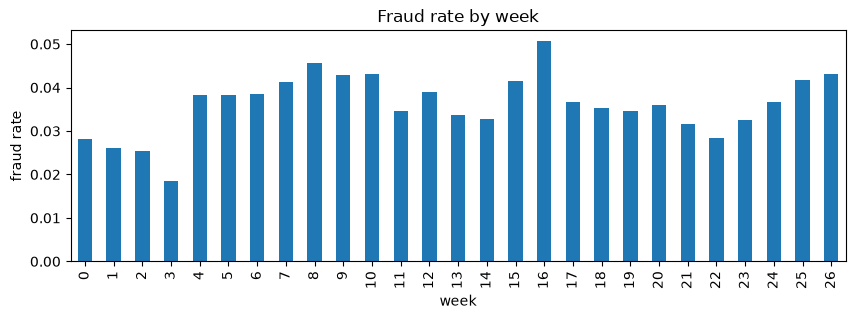

In [9]:
dt = df["TransactionDT"]
print("min:", dt.min(), "max:", dt.max())
print("span in days:", (dt.max() - dt.min()) / (60 * 60 * 24))

# is the data already sorted by time?
print("sorted by TransactionDT:", dt.is_monotonic_increasing)

# does the fraud rate drift over time? (weekly buckets)
df["day"] = dt // (60 * 60 * 24)
weekly = df.groupby(df["day"] // 7)["isFraud"].mean()
ax = weekly.plot(kind="bar", figsize=(10, 3), title="Fraud rate by week")
ax.set_xlabel("week"); ax.set_ylabel("fraud rate");

# --- What's actually in this dataset? ---
groups = {
    "TransactionDT":  "seconds from a reference point (the time axis)",
    "TransactionAmt": "transaction amount USD",
    "ProductCD":      "product code (W/C/R/H/S) — categorical",
    "card1-card6":    "card info: bank, type, network (e.g. visa/debit) — mostly categorical",
    "addr1, addr2":   "billing region / country codes",
    "dist1, dist2":   "distances (e.g. billing vs purchaser address)",
    "P_/R_emaildomain": "purchaser / recipient email domain",
    "C1-C14":         "counts (e.g. addresses linked to this card) — meaning anonymized",
    "D1-D15":         "timedeltas (e.g. days since previous transaction)",
    "M1-M9":          "match flags (do card and address match? T/F)",
    "V1-V339":        "Vesta-engineered features (rankings/ratios) — meaning anonymized",
    "id_01-id_38":    "identity: network/proof-of-ID signals — anonymized",
    "DeviceType/Info":"desktop vs mobile, device model string",
}
for k, v in groups.items(): print(f"{k:18s} {v}")

import re
def col_group(c):
    return re.sub(r"\d+$", "*", c)  # C1->C*, V339->V*

summary = (pd.DataFrame({"grp": [col_group(c) for c in df.columns],
                         "missing": df.isna().mean().values})
             .groupby("grp").agg(n_cols=("missing", "size"),
                                 avg_missing=("missing", "mean")).round(2))
print(summary.sort_values("n_cols", ascending=False).head(15))



In [4]:
df = df.sort_values("TransactionDT").reset_index(drop=True)

n = len(df)
i_val  = int(n * 0.60)   # first 60% of TIME -> train
i_test = int(n * 0.80)   # next 20% -> validation, last 20% -> test

train = df.iloc[:i_val]
val   = df.iloc[i_val:i_test]
test  = df.iloc[i_test:]

for name, part in [("train", train), ("val", val), ("test", test)]:
    days = (part["TransactionDT"].max() - part["TransactionDT"].min()) / 86400
    print(f"{name:5s}  rows={len(part):7d}  span={days:5.1f} days  "
          f"fraud rate={part['isFraud'].mean():.4f}")


train  rows= 354324  span=100.2 days  fraud rate=0.0338
val    rows= 118108  span= 39.9 days  fraud rate=0.0390
test   rows= 118108  span= 41.9 days  fraud rate=0.0344


In [6]:
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix

def evaluate(y_true, proba, threshold=0.5, name=""):
    """Standard evaluation: threshold-free ranking metrics + thresholded confusion."""
    tn, fp, fn, tp = confusion_matrix(y_true, proba >= threshold).ravel()
    return {
        "name":      name,
        "pr_auc":    round(average_precision_score(y_true, proba), 4),  # primary
        "roc_auc":   round(roc_auc_score(y_true, proba), 4),
        "threshold": threshold,
        "recall":    round(tp / (tp + fn), 4),
        "precision": round(tp / (tp + fp), 4) if tp + fp else 0.0,
        "flagged":   int(tp + fp),      # investigator workload
        "missed_fraud": int(fn),
    }

def pick_threshold_for_budget(proba, budget):
    """Highest threshold that flags at most `budget` claims — set ON VALIDATION ONLY."""
    return float(np.quantile(proba, 1 - budget / len(proba)))


In [7]:
from xgboost import XGBClassifier

feature_cols = (train.select_dtypes(include=[np.number])
                     .columns.drop(["isFraud", "TransactionID", "day"]))

X_train, y_train = train[feature_cols], train["isFraud"]
X_val,   y_val   = val[feature_cols],   val["isFraud"]
X_test,  y_test  = test[feature_cols],  test["isFraud"]

model = XGBClassifier(tree_method="hist", eval_metric="logloss",
                      n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

proba_val  = model.predict_proba(X_val)[:, 1]
proba_test = model.predict_proba(X_test)[:, 1]

results = [
    {"name": "01 random split (leaky)", "pr_auc": 0.6925, "roc_auc": 0.9362},
    evaluate(y_val,  proba_val,  name="02 temporal — VAL"),
    evaluate(y_test, proba_test, name="02 temporal — TEST"),
]
pd.DataFrame(results).set_index("name")


,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
01 random split (leaky),0.6925,0.9362,NaN,NaN,NaN,NaN,NaN
02 temporal — VAL,0.5571,0.9050,0.5,0.3847,0.7798,2275.0,2837.0
02 temporal — TEST,0.4476,0.8728,0.5,0.3265,0.6543,2028.0,2737.0


In [8]:
BUDGET = 3000  # investigator capacity per period (scaled to split size)

thr = pick_threshold_for_budget(proba_val, BUDGET)          # decided on VAL
print(f"budget threshold chosen on val: {thr:.4f}\n")

final = pd.DataFrame([
    evaluate(y_val,  proba_val,  threshold=thr, name="val  @ budget-thr"),
    evaluate(y_test, proba_test, threshold=thr, name="test @ budget-thr"),   # reported
]).set_index("name")
final


budget threshold chosen on val: 0.3143



,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
val @ budget-thr,0.5571,0.9050,0.314342,0.4487,0.6897,3000,2542
test @ budget-thr,0.4476,0.8728,0.314342,0.3733,0.5475,2771,2547
